<a href="https://colab.research.google.com/github/UsmanArif169/Machine-Learning-Algorithms-/blob/main/Polynomial_linear__Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

In [2]:
X = 6 * np.random.rand(200,1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200,1)

# y = 0.8x^2 + 0.9x + 2

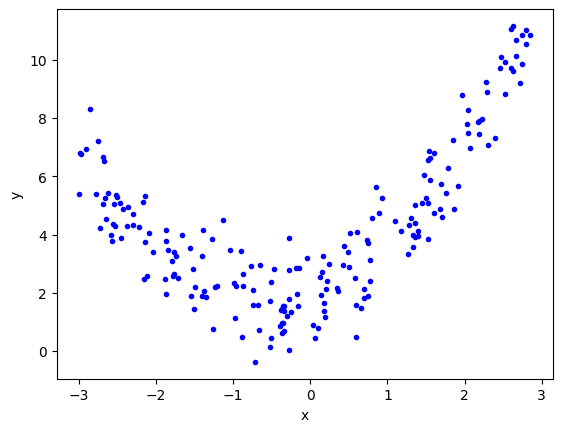

In [6]:
import matplotlib.pyplot as plt
plt.plot(X,y,'b.')
plt.xlabel('x')
plt.ylabel('y')
plt.show()


In [7]:
# Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)

In [8]:
# Applying Linear regression

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [9]:
# prediction

y_pred = lr.predict(X_test)

In [10]:
# find r2_score

from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.14342661120776812

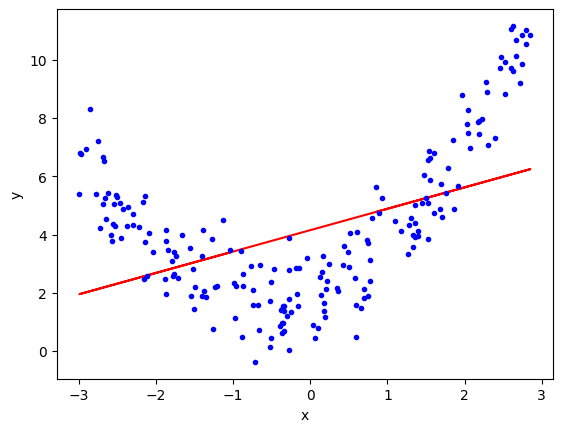

In [11]:
plt.plot(X_train, lr.predict(X_train), 'r-')
plt.plot(X, y, 'b.')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [12]:
# Applying Polynomial Linear Regression degree = 2

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
poly = PolynomialFeatures(degree =2, include_bias = False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [13]:
print(X_train[0])
print(X_train_poly[0])

[-1.0368157]
[-1.0368157  1.0749868]


In [14]:
lr = LinearRegression()
lr.fit(X_train_poly, y_train)

LinearRegression()

In [15]:
y_pred = lr.predict(X_test_poly)

In [16]:
r2_score(y_test, y_pred)

0.8807298483413921

In [17]:
print(lr.coef_)
print(lr.intercept_)

[[0.90984262 0.81818679]]
[1.97814409]


In [19]:
X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

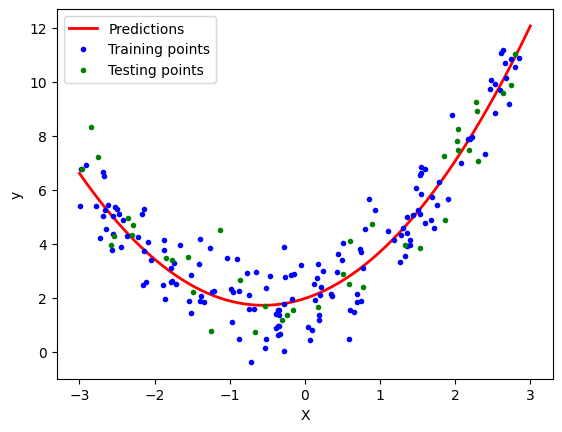

In [20]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [21]:
# 3D polynomial regression
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y +2 + np.random.randn(100, 1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

In [22]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

In [23]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input,y_input)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

In [24]:
import plotly.graph_objects as go

fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final ))

fig.show()

In [26]:
X_multi = np.array([x,y]).reshape(100,2)
X_multi.shape

(100, 2)

In [27]:
poly = PolynomialFeatures(degree=30)
X_multi_trans = poly.fit_transform(X_multi)